## Load packages

In [1]:
import os
import glob

import chardet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno # run first '%pip install missingno'
from ydata_profiling import ProfileReport # run first '%pip install ydata_profiling'

import xml.etree.ElementTree as ET # pip install lxml

import sys
sys.path.insert(0, '..')
from models.tools import show_info, get_alerts, dump_missing, parse_xml, plot_correlation, drop_na_and_zeros, get_common_index, add_date_features

pd.set_option('display.max_rows', 100)
plt.style.use("ggplot")

/Users/jshen/neuefische/capstone_solar_energy/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## OPSD - House holds

> https://data.open-power-system-data.org/household_data/2020-04-15

> Detailed household load and solar generation in minutely to hourly resolution

#### Columns

In [2]:
# Dump the column information as a markdown code for creating a table

import json

js_str = """
{
"15min": {
            "primaryKey": "utc_timestamp",
            "missingValue": "",
            "fields": [
                {
                    "name": "utc_timestamp",
                    "description": "Start of timeperiod in Coordinated Universal Time",
                    "type": "datetime",
                    "format": "fmt:%Y-%m-%dT%H%M%SZ",
                    "opsd-contentfilter": true
                },
                {
                    "name": "cet_cest_timestamp",
                    "description": "Start of timeperiod in Central European (Summer-) Time",
                    "type": "datetime",
                    "format": "fmt:%Y-%m-%dT%H%M%S%z"
                },
                {
                    "name": "interpolated",
                    "description": "marker to indicate which columns are missing data in source data and has been interpolated (e.g. DE_KN_Residential1_grid_import;)",
                    "type": "string"
                },
                {
                    "name": "DE_KN_industrial1_grid_import",
                    "description": "Energy imported from the public grid in a industrial warehouse building in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_warehouse",
                        "Household": "industrial1",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_industrial1_pv_1",
                    "description": "Total Photovoltaic energy generation in a industrial warehouse building in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_warehouse",
                        "Household": "industrial1",
                        "Feed": "pv_1"
                    }
                },
                {
                    "name": "DE_KN_industrial1_pv_2",
                    "description": "Total Photovoltaic energy generation in a industrial warehouse building in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_warehouse",
                        "Household": "industrial1",
                        "Feed": "pv_2"
                    }
                },
                {
                    "name": "DE_KN_industrial2_grid_import",
                    "description": "Energy imported from the public grid in a industrial building of a business in the crafts sector in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_craft",
                        "Household": "industrial2",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_industrial2_pv",
                    "description": "Total Photovoltaic energy generation in a industrial building of a business in the crafts sector in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_craft",
                        "Household": "industrial2",
                        "Feed": "pv"
                    }
                },
                {
                    "name": "DE_KN_industrial2_storage_charge",
                    "description": "Battery charging energy in a industrial building of a business in the crafts sector in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_craft",
                        "Household": "industrial2",
                        "Feed": "storage_charge"
                    }
                },
                {
                    "name": "DE_KN_industrial2_storage_decharge",
                    "description": "Energy in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_craft",
                        "Household": "industrial2",
                        "Feed": "storage_decharge"
                    }
                },
                {
                    "name": "DE_KN_industrial3_area_offices",
                    "description": "Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "area_offices"
                    }
                },
                {
                    "name": "DE_KN_industrial3_area_room_1",
                    "description": "Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "area_room_1"
                    }
                },
                {
                    "name": "DE_KN_industrial3_area_room_2",
                    "description": "Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "area_room_2"
                    }
                },
                {
                    "name": "DE_KN_industrial3_area_room_3",
                    "description": "Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "area_room_3"
                    }
                },
                {
                    "name": "DE_KN_industrial3_area_room_4",
                    "description": "Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "area_room_4"
                    }
                },
                {
                    "name": "DE_KN_industrial3_compressor",
                    "description": "Compressor energy consumption in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "compressor"
                    }
                },
                {
                    "name": "DE_KN_industrial3_cooling_aggregate",
                    "description": "Cooling aggregate energy consumption in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "cooling_aggregate"
                    }
                },
                {
                    "name": "DE_KN_industrial3_cooling_pumps",
                    "description": "Cooling pumps energy consumption in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "cooling_pumps"
                    }
                },
                {
                    "name": "DE_KN_industrial3_dishwasher",
                    "description": "Dishwasher energy consumption in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "dishwasher"
                    }
                },
                {
                    "name": "DE_KN_industrial3_ev",
                    "description": "Electric Vehicle charging energy in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "ev"
                    }
                },
                {
                    "name": "DE_KN_industrial3_grid_import",
                    "description": "Energy imported from the public grid in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_industrial3_machine_1",
                    "description": "Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "machine_1"
                    }
                },
                {
                    "name": "DE_KN_industrial3_machine_2",
                    "description": "Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "machine_2"
                    }
                },
                {
                    "name": "DE_KN_industrial3_machine_3",
                    "description": "Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "machine_3"
                    }
                },
                {
                    "name": "DE_KN_industrial3_machine_4",
                    "description": "Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "machine_4"
                    }
                },
                {
                    "name": "DE_KN_industrial3_machine_5",
                    "description": "Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "machine_5"
                    }
                },
                {
                    "name": "DE_KN_industrial3_pv_facade",
                    "description": "Total Photovoltaic energy generation in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "pv_facade"
                    }
                },
                {
                    "name": "DE_KN_industrial3_pv_roof",
                    "description": "Total Photovoltaic energy generation in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "pv_roof"
                    }
                },
                {
                    "name": "DE_KN_industrial3_refrigerator",
                    "description": "Refrigerator energy consumption in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "refrigerator"
                    }
                },
                {
                    "name": "DE_KN_industrial3_ventilation",
                    "description": "Ventilation energy consumption in a industrial building, part of a research institute in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "industrial_building_institute",
                        "Household": "industrial3",
                        "Feed": "ventilation"
                    }
                },
                {
                    "name": "DE_KN_public1_grid_import",
                    "description": "Energy imported from the public grid in a school building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "school_building_urban",
                        "Household": "public1",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_public2_grid_import",
                    "description": "Energy imported from the public grid in a school building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "school_building_urban",
                        "Household": "public2",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_residential1_dishwasher",
                    "description": "Dishwasher energy consumption in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential1",
                        "Feed": "dishwasher"
                    }
                },
                {
                    "name": "DE_KN_residential1_freezer",
                    "description": "Freezer energy consumption in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential1",
                        "Feed": "freezer"
                    }
                },
                {
                    "name": "DE_KN_residential1_grid_import",
                    "description": "Energy imported from the public grid in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential1",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_residential1_heat_pump",
                    "description": "Heat pump energy consumption in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential1",
                        "Feed": "heat_pump"
                    }
                },
                {
                    "name": "DE_KN_residential1_pv",
                    "description": "Total Photovoltaic energy generation in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential1",
                        "Feed": "pv"
                    }
                },
                {
                    "name": "DE_KN_residential1_washing_machine",
                    "description": "Washing machine energy consumption in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential1",
                        "Feed": "washing_machine"
                    }
                },
                {
                    "name": "DE_KN_residential2_circulation_pump",
                    "description": "Circulation pump energy consumption in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential2",
                        "Feed": "circulation_pump"
                    }
                },
                {
                    "name": "DE_KN_residential2_dishwasher",
                    "description": "Dishwasher energy consumption in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential2",
                        "Feed": "dishwasher"
                    }
                },
                {
                    "name": "DE_KN_residential2_freezer",
                    "description": "Freezer energy consumption in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential2",
                        "Feed": "freezer"
                    }
                },
                {
                    "name": "DE_KN_residential2_grid_import",
                    "description": "Energy imported from the public grid in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential2",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_residential2_washing_machine",
                    "description": "Washing machine energy consumption in a residential building, located in the suburban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_suburb",
                        "Household": "residential2",
                        "Feed": "washing_machine"
                    }
                },
                {
                    "name": "DE_KN_residential3_circulation_pump",
                    "description": "Circulation pump energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential3",
                        "Feed": "circulation_pump"
                    }
                },
                {
                    "name": "DE_KN_residential3_dishwasher",
                    "description": "Dishwasher energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential3",
                        "Feed": "dishwasher"
                    }
                },
                {
                    "name": "DE_KN_residential3_freezer",
                    "description": "Freezer energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential3",
                        "Feed": "freezer"
                    }
                },
                {
                    "name": "DE_KN_residential3_grid_export",
                    "description": "Energy exported to the public grid in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential3",
                        "Feed": "grid_export"
                    }
                },
                {
                    "name": "DE_KN_residential3_grid_import",
                    "description": "Energy imported from the public grid in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential3",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_residential3_pv",
                    "description": "Total Photovoltaic energy generation in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential3",
                        "Feed": "pv"
                    }
                },
                {
                    "name": "DE_KN_residential3_refrigerator",
                    "description": "Refrigerator energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential3",
                        "Feed": "refrigerator"
                    }
                },
                {
                    "name": "DE_KN_residential3_washing_machine",
                    "description": "Washing machine energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential3",
                        "Feed": "washing_machine"
                    }
                },
                {
                    "name": "DE_KN_residential4_dishwasher",
                    "description": "Dishwasher energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "dishwasher"
                    }
                },
                {
                    "name": "DE_KN_residential4_ev",
                    "description": "Electric Vehicle charging energy in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "ev"
                    }
                },
                {
                    "name": "DE_KN_residential4_freezer",
                    "description": "Freezer energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "freezer"
                    }
                },
                {
                    "name": "DE_KN_residential4_grid_export",
                    "description": "Energy exported to the public grid in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "grid_export"
                    }
                },
                {
                    "name": "DE_KN_residential4_grid_import",
                    "description": "Energy imported from the public grid in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_residential4_heat_pump",
                    "description": "Heat pump energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "heat_pump"
                    }
                },
                {
                    "name": "DE_KN_residential4_pv",
                    "description": "Total Photovoltaic energy generation in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "pv"
                    }
                },
                {
                    "name": "DE_KN_residential4_refrigerator",
                    "description": "Refrigerator energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "refrigerator"
                    }
                },
                {
                    "name": "DE_KN_residential4_washing_machine",
                    "description": "Washing machine energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential4",
                        "Feed": "washing_machine"
                    }
                },
                {
                    "name": "DE_KN_residential5_dishwasher",
                    "description": "Dishwasher energy consumption in a residential apartment, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_apartment_urban",
                        "Household": "residential5",
                        "Feed": "dishwasher"
                    }
                },
                {
                    "name": "DE_KN_residential5_grid_import",
                    "description": "Energy imported from the public grid in a residential apartment, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_apartment_urban",
                        "Household": "residential5",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_residential5_refrigerator",
                    "description": "Refrigerator energy consumption in a residential apartment, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_apartment_urban",
                        "Household": "residential5",
                        "Feed": "refrigerator"
                    }
                },
                {
                    "name": "DE_KN_residential5_washing_machine",
                    "description": "Washing machine energy consumption in a residential apartment, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_apartment_urban",
                        "Household": "residential5",
                        "Feed": "washing_machine"
                    }
                },
                {
                    "name": "DE_KN_residential6_circulation_pump",
                    "description": "Circulation pump energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential6",
                        "Feed": "circulation_pump"
                    }
                },
                {
                    "name": "DE_KN_residential6_dishwasher",
                    "description": "Dishwasher energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential6",
                        "Feed": "dishwasher"
                    }
                },
                {
                    "name": "DE_KN_residential6_freezer",
                    "description": "Freezer energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential6",
                        "Feed": "freezer"
                    }
                },
                {
                    "name": "DE_KN_residential6_grid_export",
                    "description": "Energy exported to the public grid in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential6",
                        "Feed": "grid_export"
                    }
                },
                {
                    "name": "DE_KN_residential6_grid_import",
                    "description": "Energy imported from the public grid in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential6",
                        "Feed": "grid_import"
                    }
                },
                {
                    "name": "DE_KN_residential6_pv",
                    "description": "Total Photovoltaic energy generation in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential6",
                        "Feed": "pv"
                    }
                },
                {
                    "name": "DE_KN_residential6_washing_machine",
                    "description": "Washing machine energy consumption in a residential building, located in the urban area in kWh",
                    "type": "number (float)",
                    "unit": "kWh",
                    "opsd-properties": {
                        "Region": "DE_KN",
                        "Type": "residential_building_urban",
                        "Household": "residential6",
                        "Feed": "washing_machine"
                    }
                }
            ]
        }
}

"""

# data = json.loads(js_str)
# markdown_str = "| Field Name | Type (Format) | Description |\n|---|---|---|\n"

# for field in data['fields']:
#     field_name = field['name']
#     field_type = field['type']
#     if 'format' in field:
#         field_type += f" ({field['format']})"
#     description = field['description']
#     markdown_str += f"| {field_name} | {field_type} | {description} |\n"

# print(markdown_str)

# Parse the JSON string
data = json.loads(js_str)

# Extract the fields
fields = data["15min"]["fields"]

# Generate the markdown code
markdown_code = "| Field Name | Type (Format) | Description |\n| --- | --- | --- |\n"

for field in fields:
    field_name = field["name"]
    field_type = field["type"]
    field_format = field.get("format", "")
    field_description = field["description"]
    
    type_format = field_type + (" (" + field_format + ")" if field_format else "")
    
    markdown_code += f"| {field_name} | {type_format} | {field_description} |\n"

# Print the markdown code
# print(markdown_code)

- **Table of Columns**

| Field Name | Type (Format) | Description |
| --- | --- | --- |
| utc_timestamp | datetime (fmt:%Y-%m-%dT%H%M%SZ) | Start of timeperiod in Coordinated Universal Time |
| cet_cest_timestamp | datetime (fmt:%Y-%m-%dT%H%M%S%z) | Start of timeperiod in Central European (Summer-) Time |
| interpolated | string | marker to indicate which columns are missing data in source data and has been interpolated (e.g. DE_KN_Residential1_grid_import;) |
| DE_KN_industrial1_grid_import | number (float) | Energy imported from the public grid in a industrial warehouse building in kWh |
| DE_KN_industrial1_pv_1 | number (float) | Total Photovoltaic energy generation in a industrial warehouse building in kWh |
| DE_KN_industrial1_pv_2 | number (float) | Total Photovoltaic energy generation in a industrial warehouse building in kWh |
| DE_KN_industrial2_grid_import | number (float) | Energy imported from the public grid in a industrial building of a business in the crafts sector in kWh |
| DE_KN_industrial2_pv | number (float) | Total Photovoltaic energy generation in a industrial building of a business in the crafts sector in kWh |
| DE_KN_industrial2_storage_charge | number (float) | Battery charging energy in a industrial building of a business in the crafts sector in kWh |
| DE_KN_industrial2_storage_decharge | number (float) | Energy in kWh |
| DE_KN_industrial3_area_offices | number (float) | Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_area_room_1 | number (float) | Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_area_room_2 | number (float) | Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_area_room_3 | number (float) | Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_area_room_4 | number (float) | Energy consumption of an area, consisting of several smaller loads, in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_compressor | number (float) | Compressor energy consumption in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_cooling_aggregate | number (float) | Cooling aggregate energy consumption in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_cooling_pumps | number (float) | Cooling pumps energy consumption in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_dishwasher | number (float) | Dishwasher energy consumption in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_ev | number (float) | Electric Vehicle charging energy in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_grid_import | number (float) | Energy imported from the public grid in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_machine_1 | number (float) | Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_machine_2 | number (float) | Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_machine_3 | number (float) | Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_machine_4 | number (float) | Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_machine_5 | number (float) | Energy consumption of an industrial- or research-machine in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_pv_facade | number (float) | Total Photovoltaic energy generation in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_pv_roof | number (float) | Total Photovoltaic energy generation in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_refrigerator | number (float) | Refrigerator energy consumption in a industrial building, part of a research institute in kWh |
| DE_KN_industrial3_ventilation | number (float) | Ventilation energy consumption in a industrial building, part of a research institute in kWh |
| DE_KN_public1_grid_import | number (float) | Energy imported from the public grid in a school building, located in the urban area in kWh |
| DE_KN_public2_grid_import | number (float) | Energy imported from the public grid in a school building, located in the urban area in kWh |
| DE_KN_residential1_dishwasher | number (float) | Dishwasher energy consumption in a residential building, located in the suburban area in kWh |
| DE_KN_residential1_freezer | number (float) | Freezer energy consumption in a residential building, located in the suburban area in kWh |
| DE_KN_residential1_grid_import | number (float) | Energy imported from the public grid in a residential building, located in the suburban area in kWh |
| DE_KN_residential1_heat_pump | number (float) | Heat pump energy consumption in a residential building, located in the suburban area in kWh |
| DE_KN_residential1_pv | number (float) | Total Photovoltaic energy generation in a residential building, located in the suburban area in kWh |
| DE_KN_residential1_washing_machine | number (float) | Washing machine energy consumption in a residential building, located in the suburban area in kWh |
| DE_KN_residential2_circulation_pump | number (float) | Circulation pump energy consumption in a residential building, located in the suburban area in kWh |
| DE_KN_residential2_dishwasher | number (float) | Dishwasher energy consumption in a residential building, located in the suburban area in kWh |
| DE_KN_residential2_freezer | number (float) | Freezer energy consumption in a residential building, located in the suburban area in kWh |
| DE_KN_residential2_grid_import | number (float) | Energy imported from the public grid in a residential building, located in the suburban area in kWh |
| DE_KN_residential2_washing_machine | number (float) | Washing machine energy consumption in a residential building, located in the suburban area in kWh |
| DE_KN_residential3_circulation_pump | number (float) | Circulation pump energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential3_dishwasher | number (float) | Dishwasher energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential3_freezer | number (float) | Freezer energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential3_grid_export | number (float) | Energy exported to the public grid in a residential building, located in the urban area in kWh |
| DE_KN_residential3_grid_import | number (float) | Energy imported from the public grid in a residential building, located in the urban area in kWh |
| DE_KN_residential3_pv | number (float) | Total Photovoltaic energy generation in a residential building, located in the urban area in kWh |
| DE_KN_residential3_refrigerator | number (float) | Refrigerator energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential3_washing_machine | number (float) | Washing machine energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential4_dishwasher | number (float) | Dishwasher energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential4_ev | number (float) | Electric Vehicle charging energy in a residential building, located in the urban area in kWh |
| DE_KN_residential4_freezer | number (float) | Freezer energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential4_grid_export | number (float) | Energy exported to the public grid in a residential building, located in the urban area in kWh |
| DE_KN_residential4_grid_import | number (float) | Energy imported from the public grid in a residential building, located in the urban area in kWh |
| DE_KN_residential4_heat_pump | number (float) | Heat pump energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential4_pv | number (float) | Total Photovoltaic energy generation in a residential building, located in the urban area in kWh |
| DE_KN_residential4_refrigerator | number (float) | Refrigerator energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential4_washing_machine | number (float) | Washing machine energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential5_dishwasher | number (float) | Dishwasher energy consumption in a residential apartment, located in the urban area in kWh |
| DE_KN_residential5_grid_import | number (float) | Energy imported from the public grid in a residential apartment, located in the urban area in kWh |
| DE_KN_residential5_refrigerator | number (float) | Refrigerator energy consumption in a residential apartment, located in the urban area in kWh |
| DE_KN_residential5_washing_machine | number (float) | Washing machine energy consumption in a residential apartment, located in the urban area in kWh |
| DE_KN_residential6_circulation_pump | number (float) | Circulation pump energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential6_dishwasher | number (float) | Dishwasher energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential6_freezer | number (float) | Freezer energy consumption in a residential building, located in the urban area in kWh |
| DE_KN_residential6_grid_export | number (float) | Energy exported to the public grid in a residential building, located in the urban area in kWh |
| DE_KN_residential6_grid_import | number (float) | Energy imported from the public grid in a residential building, located in the urban area in kWh |
| DE_KN_residential6_pv | number (float) | Total Photovoltaic energy generation in a residential building, located in the urban area in kWh |
| DE_KN_residential6_washing_machine | number (float) | Washing machine energy consumption in a residential building, located in the urban area in kWh |

### Prepare the data

In [3]:
input_file_household = "../data/OPSD/household_data_15min_singleindex.csv"

df_household = pd.read_csv(input_file_household, parse_dates=["utc_timestamp"]) # no idea why "cet_cest_timestamp" does not work
df_household.drop(columns=["cet_cest_timestamp", "interpolated"], inplace=True)
df_household.head()

,utc_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_grid_import,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine
0,2014-12-11 17:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11 18:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11 18:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11 18:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Stacked DataFrame

In [4]:
# Create a dictionary to store all DataFrame
household_df_dict = {}
# hourly data frames
hourly_household_df_dict = {}
# daily data frames
daily_household_df_dict = {}

# Define the residential categories
hh_items = [
    "residential1",
    "residential2",
    "residential3",
    "residential4",
    "residential5",
    "residential6",
]

# Loop through each residential
for hh in hh_items:
    # Create a mask that selects columns containing the current residential
    mask = df_household.columns.str.contains(hh)

    # Use the mask to select the appropriate columns from the original DataFrame
    household_df_dict[hh] = df_household.loc[:, mask].copy()

    # Add the date time back and set index
    household_df_dict[hh]["utc_timestamp"] = df_household.loc[:, "utc_timestamp"]
    household_df_dict[hh].set_index("utc_timestamp", inplace=True)

    # Remove the common prefix from each column name
    household_df_dict[hh].columns = household_df_dict[hh].columns.str.replace(
        f"DE_KN_{hh}_", ""
    )

    try:
        # Drop rows where "pv" is na
        # Remove rows where the first values of 'pv' are 0
        household_df_dict[hh] = drop_na_and_zeros(household_df_dict[hh], "pv")

        # Select the columns to be summed up
        cols_to_sum = [
            col
            for col in household_df_dict[hh].columns
            if not ("grid_" in col or "pv" in col)
        ]

        # Create the new column
        household_df_dict[hh]["load"] = household_df_dict[hh][cols_to_sum].sum(axis=1)

        # Store the original first row
        original_first_row = household_df_dict[hh].iloc[0].copy()

        # Diff
        household_df_dict[hh] = household_df_dict[hh].diff()

        # Fill the first row using the original values
        household_df_dict[hh].iloc[
            0
        ] = 0  # original_first_row does not work well in some cases

        # Resample to hourly data
        hourly_household_df_dict[hh] = (
            household_df_dict[hh].resample("1H").sum()
        )  # '1H' specifies 1-h intervals
        daily_household_df_dict[hh] = (
            household_df_dict[hh].resample("1D").sum()
        )  # '1D' specifies 1-day intervals

    except:
        print(f"{hh!r} does not have 'pv' generation")
        del household_df_dict[hh]

# Add new features to dataframe of hourly resolution
for hh, _ in hourly_household_df_dict.items():
    # Prepare the data frame
    df_ = hourly_household_df_dict[hh]

    # Add new data features
    hourly_household_df_dict[hh] = add_date_features(df_, hr=True)

# Add new features to dataframe of daily resolution
for hh, _ in daily_household_df_dict.items():
    df_ = daily_household_df_dict[hh]
    daily_household_df_dict[hh] = add_date_features(df_)

'residential2' does not have 'pv' generation
'residential5' does not have 'pv' generation


##### Time span

In [5]:
# Get the time range for each residential

for key, _ in household_df_dict.items():
    start = household_df_dict[key].index[0]
    end = household_df_dict[key].index[-1]
    print(f"{key!r}: {start} - {end}")
    # print(household_df_dict[key].columns.to_list())

'residential1': 2015-05-21 15:30:00+00:00 - 2017-03-12 23:00:00+00:00
'residential3': 2016-02-29 06:30:00+00:00 - 2018-09-25 11:30:00+00:00
'residential4': 2015-10-11 06:00:00+00:00 - 2018-02-04 23:00:00+00:00
'residential6': 2015-10-25 06:30:00+00:00 - 2018-04-08 22:00:00+00:00


In [6]:
# Get the common time range for all residential

# Call the customermized function  
common_idx = get_common_index(household_df_dict)

print(f"The common time span is: {common_idx[0]} - {common_idx[-1]}")

The common time span is: 2016-05-13 13:45:00+00:00 - 2017-01-04 19:45:00+00:00


##### Daily data

In [7]:
show_info(daily_household_df_dict["residential1"])

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,dishwasher,float64,662,0.0,263,...
1,freezer,float64,662,0.0,351,...
2,grid_import,float64,662,0.0,640,...
3,heat_pump,float64,662,0.0,620,...
4,pv,float64,662,0.0,641,...
5,washing_machine,float64,662,0.0,326,...
6,load,float64,662,0.0,661,...
7,year,int32,662,0.0,3,"{2016: 366, 2015: 225, 2017: 71}"
8,month,int32,662,0.0,12,...
9,week,UInt32,662,0.0,53,...


In [8]:
show_info(hourly_household_df_dict["residential1"])

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,dishwasher,float64,15873,0.0,529,...
1,freezer,float64,15873,0.0,241,...
2,grid_import,float64,15873,0.0,3485,...
3,heat_pump,float64,15873,0.0,4950,...
4,pv,float64,15873,0.0,5065,...
5,washing_machine,float64,15873,0.0,703,...
6,load,float64,15873,0.0,7032,...
7,year,int32,15873,0.0,3,"{2016: 8784, 2015: 5385, 2017: 1704}"
8,month,int32,15873,0.0,12,...
9,week,UInt32,15873,0.0,53,...


- (1) Correlation Matrix Plot

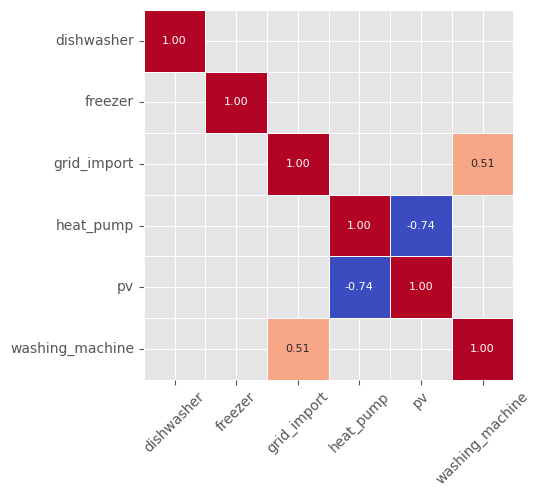

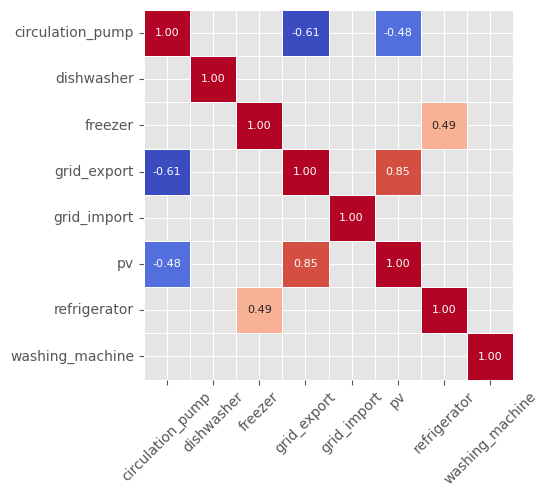

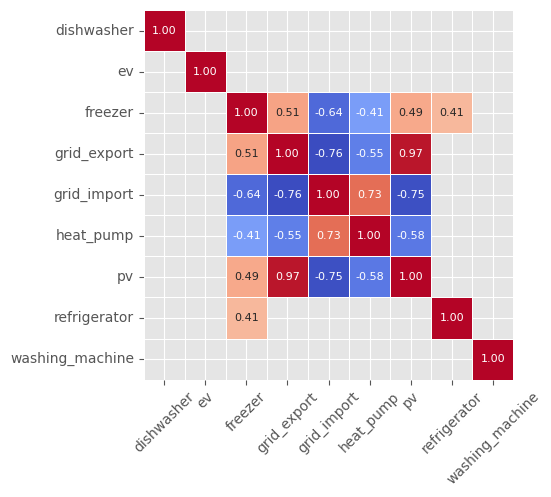

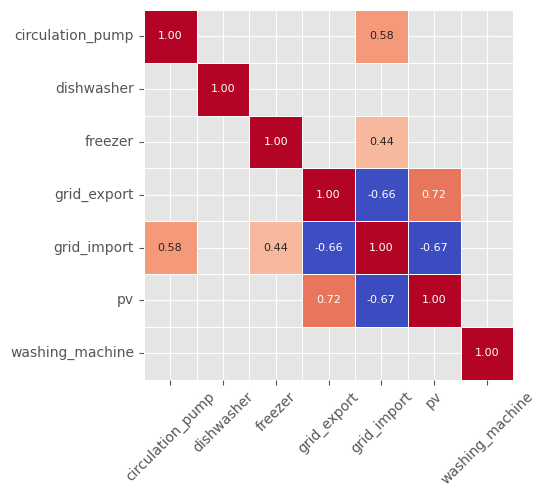

In [9]:
def plot_corr(df):
    #plt.figure(figsize=(8, 7))
    corr_matrix = df.corr()

    # Heat map
    filter = (corr_matrix >= 0.4) | (corr_matrix <= -0.4)

    ax = sns.heatmap(corr_matrix[filter], linewidths = .5, annot = True, square=True, fmt=".2f", annot_kws={"fontsize":8}, cmap='coolwarm',cbar=False)
    ax.tick_params(axis='x', rotation=45)

    plt.show()
    
date_feature_list = ["year", "month", "week", "weekday", "day", "hour"]

for key, _ in daily_household_df_dict.items():
    df_ = daily_household_df_dict[key].drop(columns=["load"])

    # Get rid of the date features
    col_to_drop = [col for col in date_feature_list if col in df_.columns]

    plot_corr(df_.drop(columns=col_to_drop))
    # plot_corr(df_)

- (2) PV vs date Plot

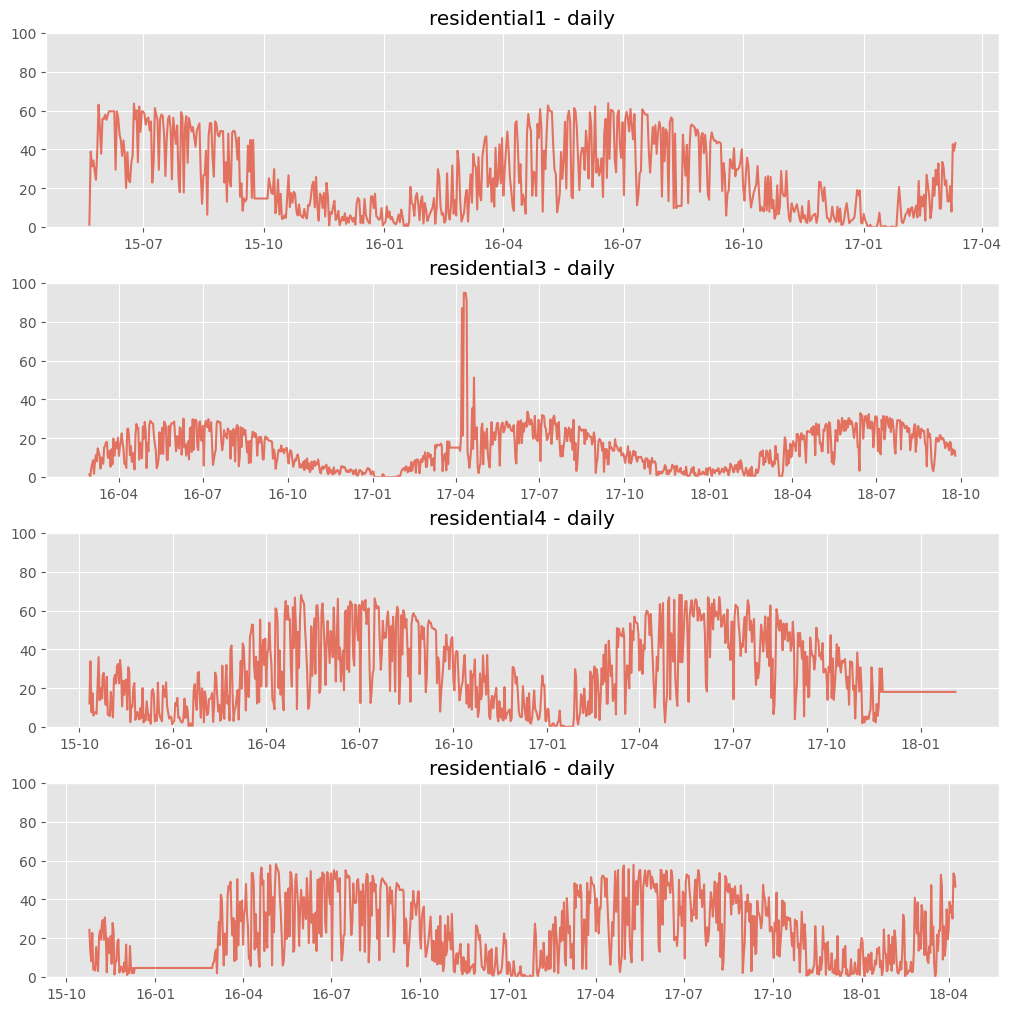

In [10]:
row = len(daily_household_df_dict)
_, axes = plt.subplots(row,1, figsize=(10, 10), constrained_layout=True, dpi=100,)


for (key, _ ), ax in zip(daily_household_df_dict.items(), axes):
    df_ = daily_household_df_dict[key].copy()
    # Filter out the data of the common time span
    # df_ = df_.loc[common_idx, :]

    

    # ax.plot(df_.index, df_[['pv', 'load']], label=["PV", "Load"], alpha=0.75)
    ax.plot(df_.index, df_[['pv']], label=["PV"], alpha=0.75)

    ax.set(
        ylim = (0, 100),
        title = f"{key} - daily",
    )

    # Get the existing labels
    labels = [item.get_text() for item in ax.get_xticklabels()]

    # Modify the labels
    new_labels = [label.replace('20', '') for label in labels]

    # Set the new labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(new_labels)

    #print(ax.get_xticklabels())

    #plt.legend()

plt.show()

- (3) EDA Plot

In [11]:
# date_feature_list = ["year", "month", "week", "weekday", "day", "hour"]

feature_dict = {
    'year': ["bar", "Year", "PV Generation (kWh)", "Total PV Generation for each Year"],
    'month': ["bar", "Month", "PV Generation (kWh)", "Average Total PV Generation over the Month"],
    #'day': ["line", "Duration of the Campaign (Days)", "Success Rate (%)", "Success Rate based on Campaign Duration"],
    # 'sub_category': ["bar", "Category", "Success Rate (%)", "Success Rate based on Campaign Category"],
    'week': ["line", "Calendar Week", "PV Generation (kWh)", "Average Total PV Generation for each Calendar Week"],
    'weekday': ["bar", "Calendar Week Day", "PV Generation (kWh)", "Average Total PV Generation for each Calendar Week Day"],
    'day': ["line", "Calendar Day", "PV Generation (kWh)", "Average Total PV Generation for each Calendar Day"],
    'hour': ["line", "Hour", "PV Generation (kWh)", "Average Total PV Generation for each Hour"],
}

def eda_count_plot(df, fea_dict, fea_item, hh):

    plt.style.use('default')
    plt.style.use('fivethirtyeight')
    
    # Set default font size
    plt.rcParams.update({'font.size': 10})

    days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    feature =  fea_item
    plot_kind, xlabel, ylabel, title = fea_dict[feature]

    # Care only "pv"
    df_ = df.groupby([feature])["pv"]

    if feature in ['month', 'week', 'day']:
        df_.mean().plot(kind=plot_kind, legend=False)
    elif feature in ['weekday']:
        df_.mean().plot(kind=plot_kind, legend=False)
        plt.gca().set_xticklabels(days)
        plt.xticks(rotation=45)
    else:
        # For "year"
        df_.sum().plot(kind=plot_kind, legend=False)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"{title}\n({hh})", fontdict={'size': 11})

    plt.show()


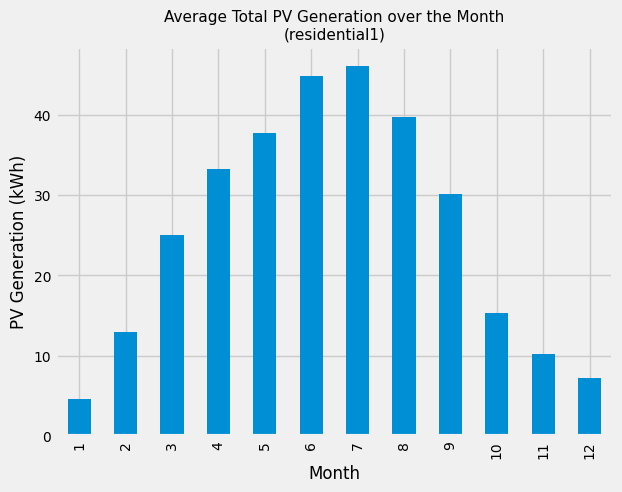

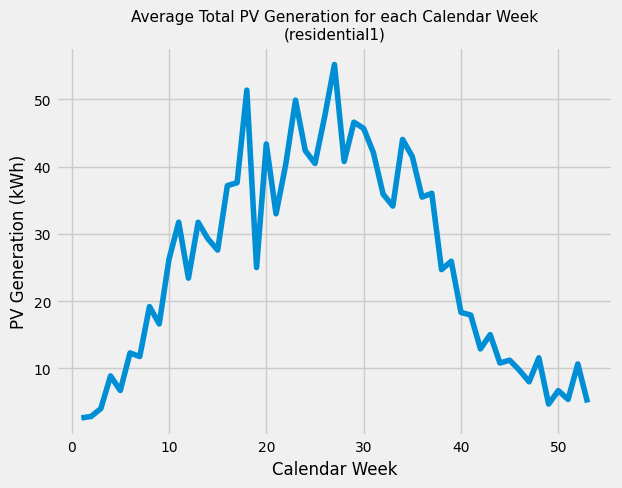

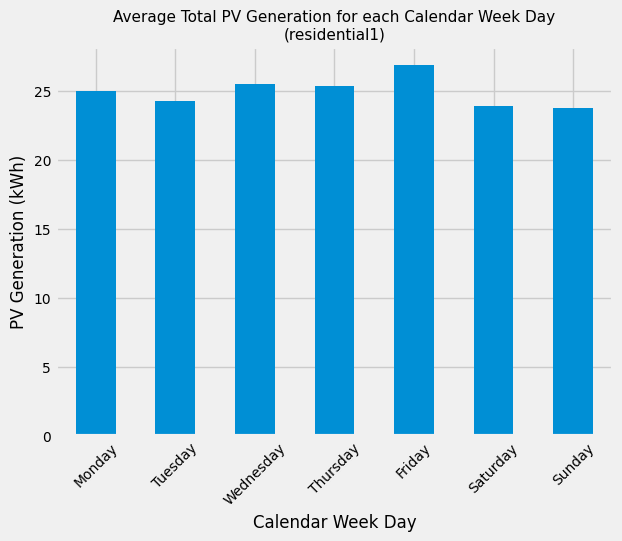

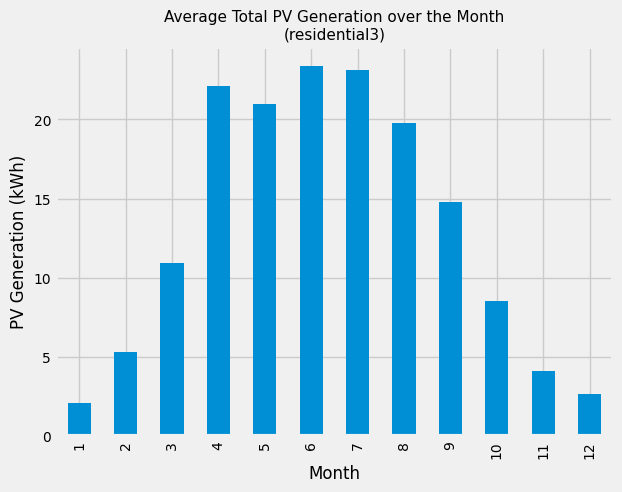

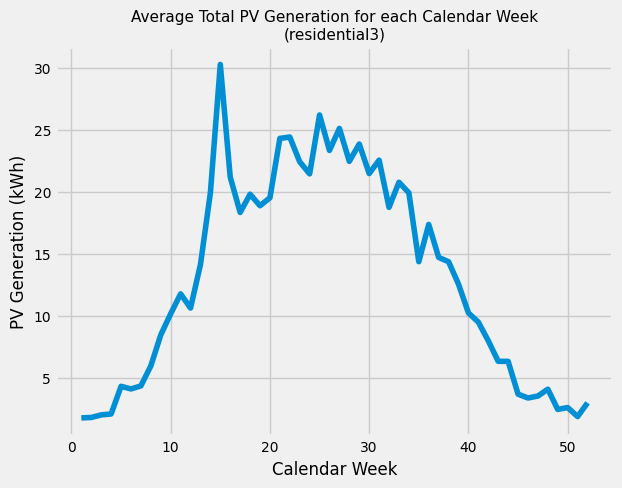

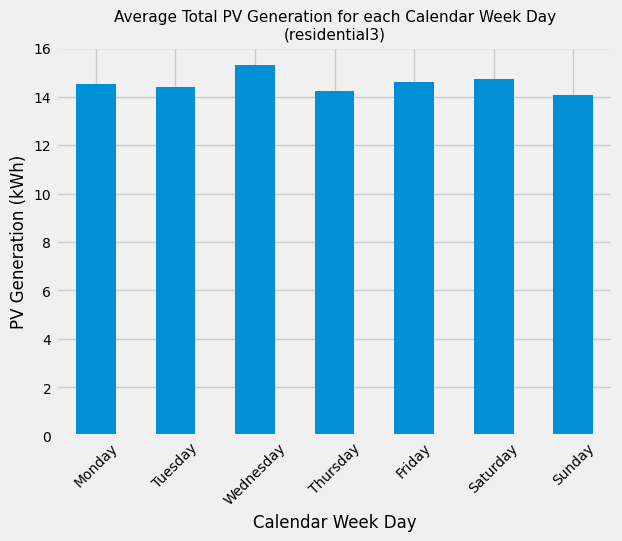

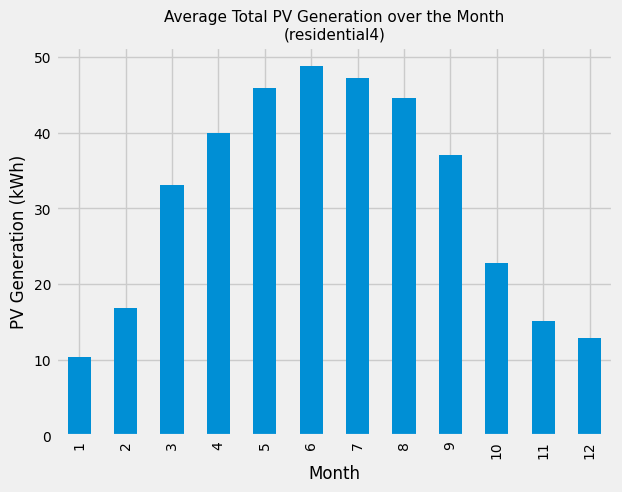

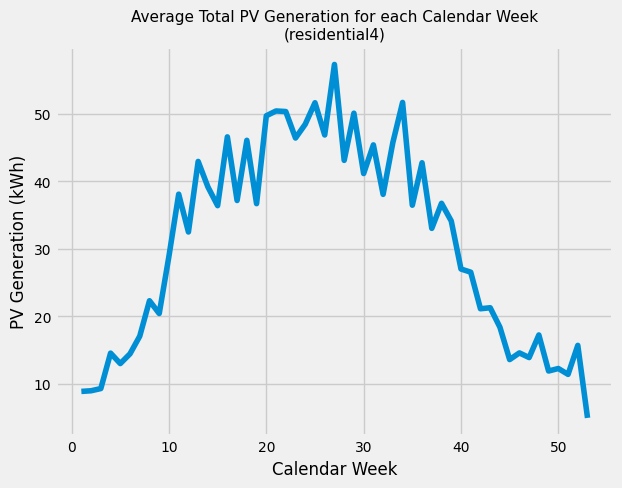

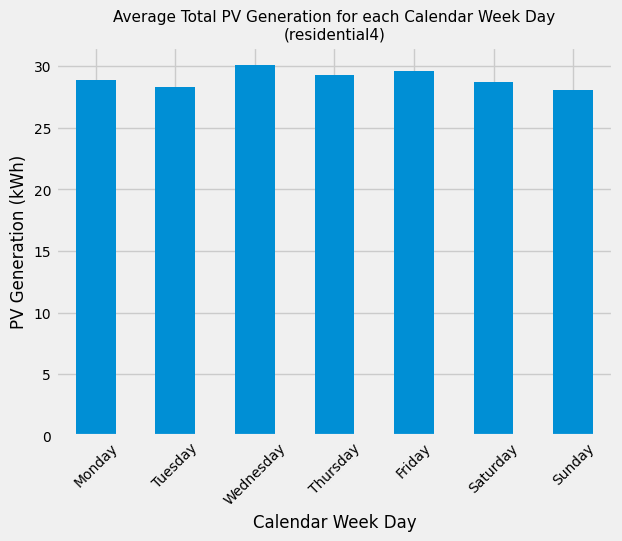

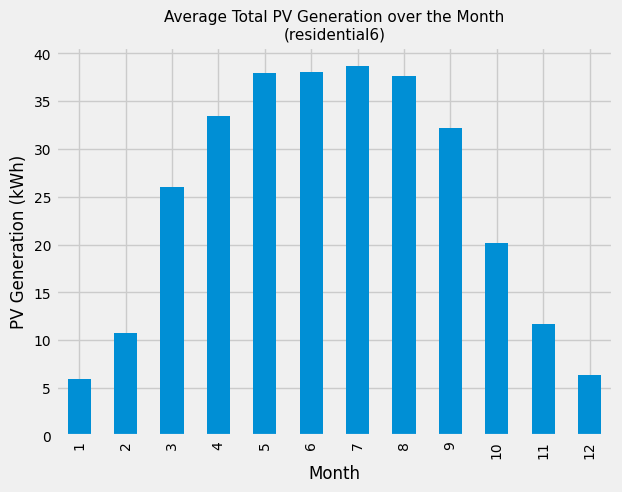

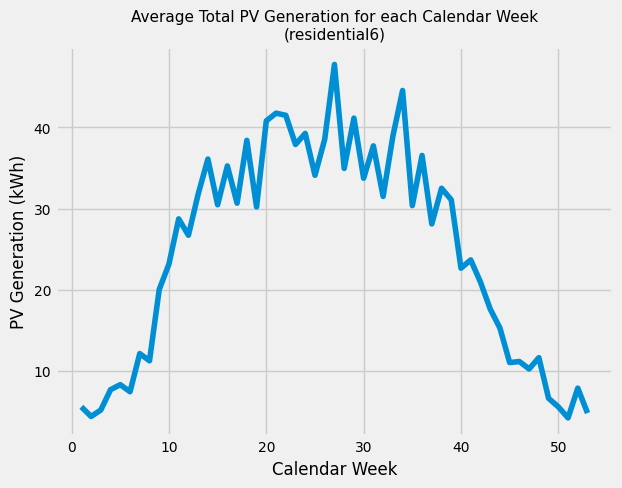

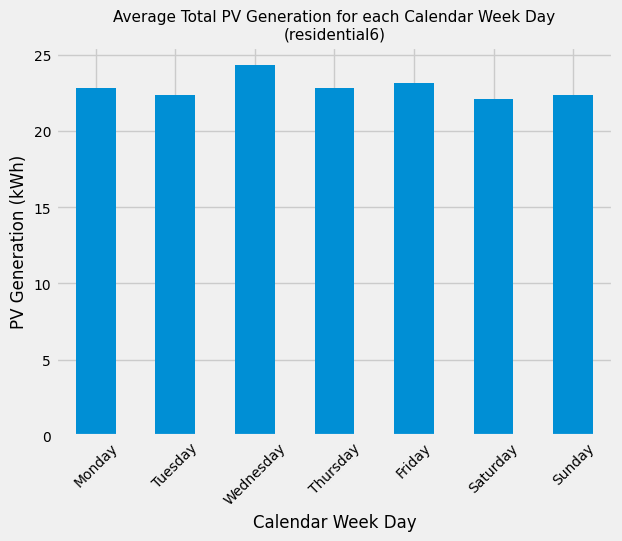

In [12]:
for hh, _ in daily_household_df_dict.items():
    #print(f"The EDA feature plots for {hh!r}")
    
    df_ = daily_household_df_dict[hh].copy()

    # Test whether a column exists or not
    feature_list = [col for col in date_feature_list if col in df_.columns]
    # Delete "year" from the list for better statistics
    feature_list.remove('year')
    
    for feature in feature_list:
        eda_count_plot(df_, feature_dict, feature, hh)

##### Hourly data

- (1) Correlation Matrix Plot

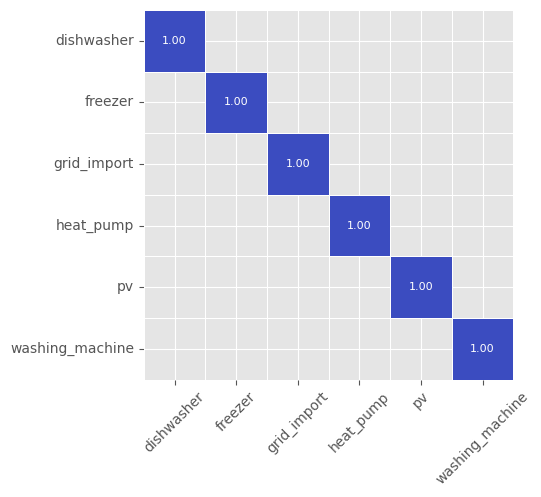

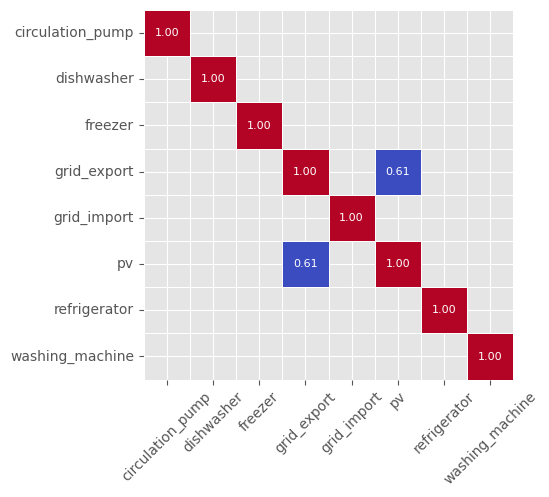

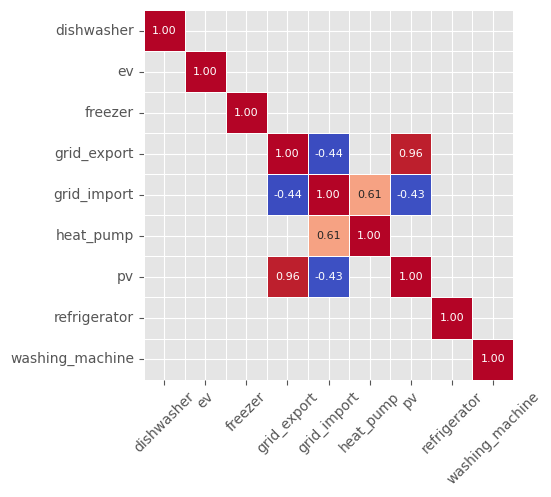

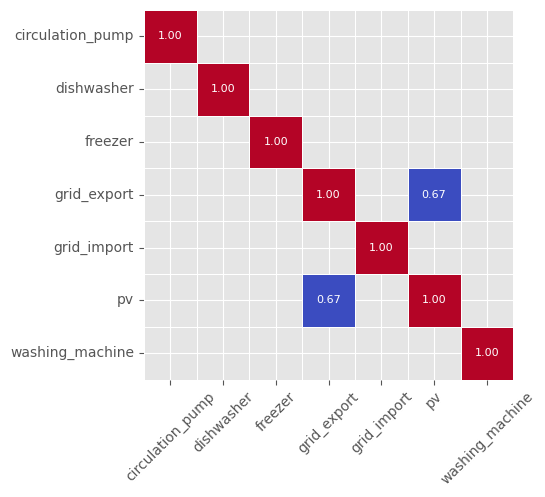

In [ ]:
for key, _ in hourly_household_df_dict.items():
    df_ = hourly_household_df_dict[key].drop(columns=["load"])

    # Get rid of the date features
    col_to_drop = [col for col in date_feature_list if col in df_.columns]

    plot_corr(df_.drop(columns=col_to_drop))

- (2) PV vs date Plot

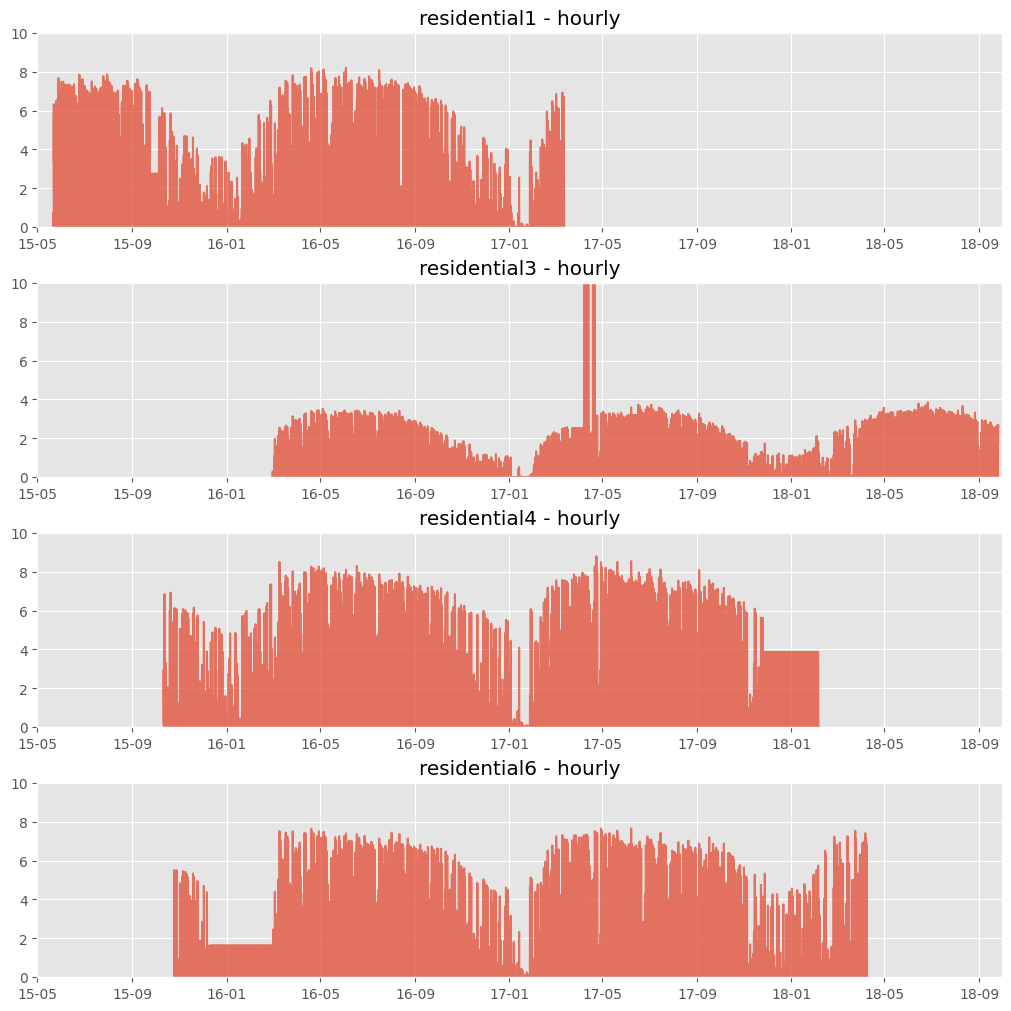

In [34]:
plt.style.use("default")
plt.style.use("ggplot")

row = len(hourly_household_df_dict)
_, axes = plt.subplots(row,1, figsize=(10, 10), constrained_layout=True, dpi=100,)


for (key, _ ), ax in zip(hourly_household_df_dict.items(), axes):
    df_ = hourly_household_df_dict[key].copy()
    # Filter out the data of the common time span
    # df_ = df_.loc[common_idx, :]

    

    # ax.plot(df_.index, df_[['pv', 'load']], label=["PV", "Load"], alpha=0.75)
    ax.plot(df_.index, df_[['pv']], label=["PV"], alpha=0.75)

    ax.set(
        xlim = (pd.to_datetime('1/5/2015', dayfirst=True), pd.to_datetime('30/09/2018', dayfirst=True)),
        ylim = (0, 10),
        title = f"{key} - hourly",
    )

    # Get the existing labels
    labels = [item.get_text() for item in ax.get_xticklabels()]

    # Modify the labels
    new_labels = [label.replace('20', '') for label in labels]

    # Set the new labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(new_labels)

    #print(ax.get_xticklabels())

    #plt.legend()

plt.show()

In [ ]:
# 'residential1': 2015-05-21 15:30:00+00:00 - 2017-03-12 23:00:00+00:00
# 'residential3': 2016-02-29 06:30:00+00:00 - 2018-09-25 11:30:00+00:00
# 'residential4': 2015-10-11 06:00:00+00:00 - 2018-02-04 23:00:00+00:00
# 'residential6': 2015-10-25 06:30:00+00:00 - 2018-04-08 22:00:00+00:00

In [14]:
hourly_household_df_dict["residential1"].head()

,dishwasher,freezer,grid_import,heat_pump,pv,washing_machine,load,year,month,week,weekday,day,hour
utc_timestamp,,,,,,,,,,,,,
2015-05-21 15:00:00+00:00,0.0,0.0,0.079,0.010,0.078,0.0,0.010,2015,5,21,3,21,15
2015-05-21 16:00:00+00:00,0.0,0.0,0.375,0.500,0.754,0.0,0.500,2015,5,21,3,21,16
2015-05-21 17:00:00+00:00,0.0,0.0,0.563,0.349,0.465,0.0,0.349,2015,5,21,3,21,17
2015-05-21 18:00:00+00:00,0.0,0.0,0.527,0.590,0.056,0.0,0.590,2015,5,21,3,21,18
2015-05-21 19:00:00+00:00,0.0,0.0,0.580,0.684,0.000,0.0,0.684,2015,5,21,3,21,19


- (3) EDA Plots

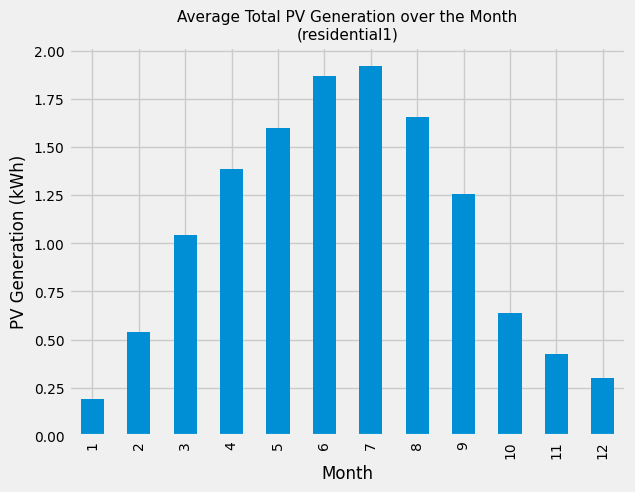

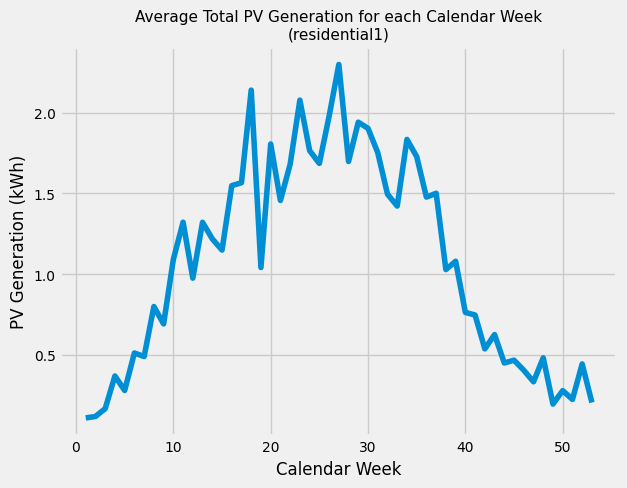

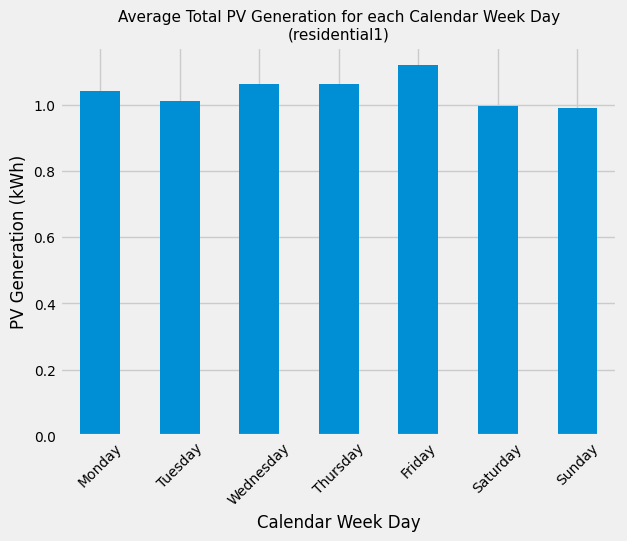

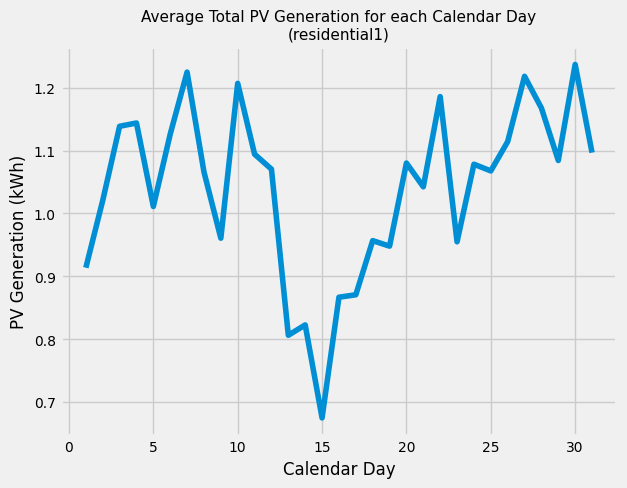

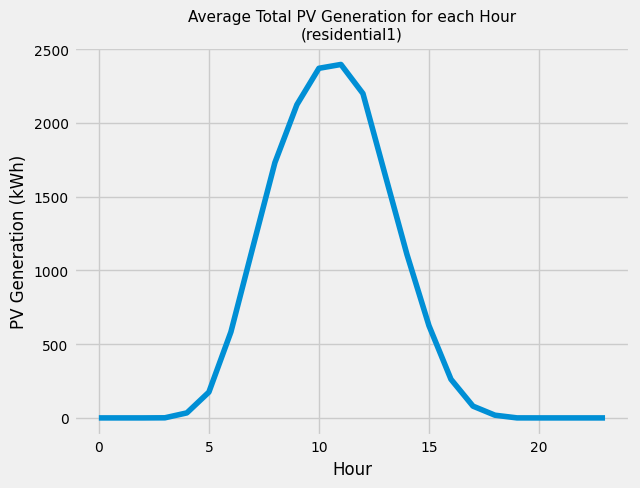

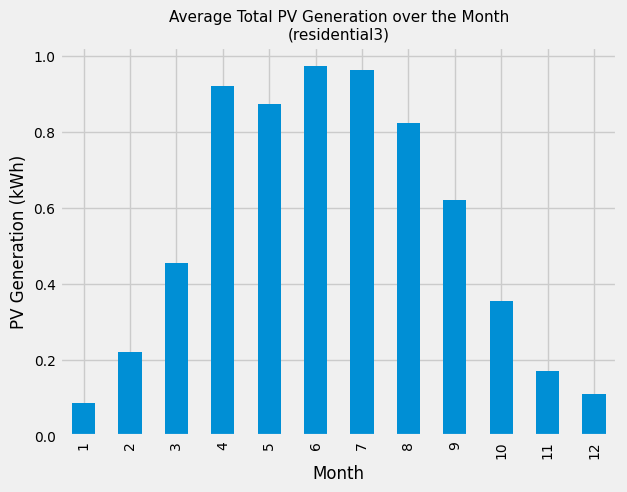

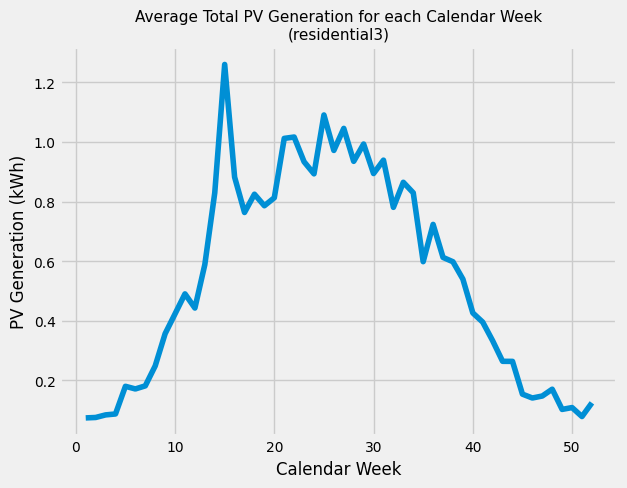

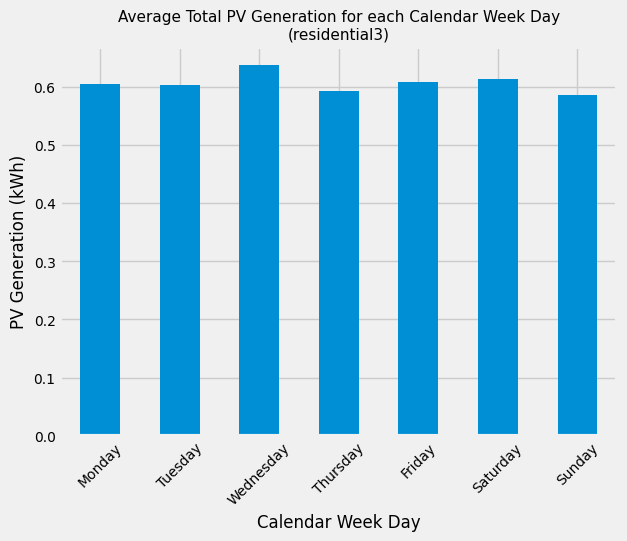

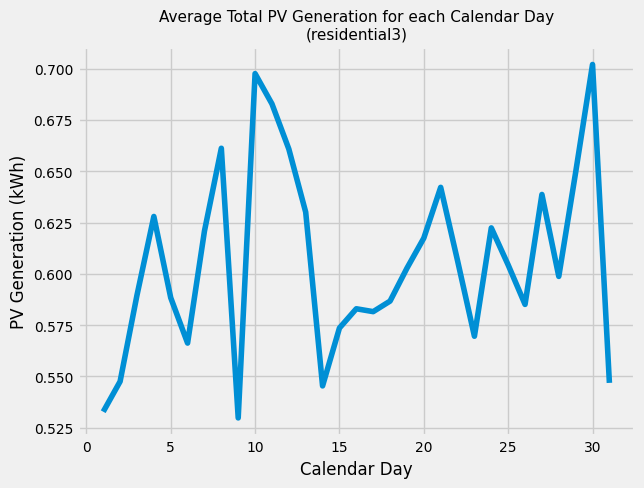

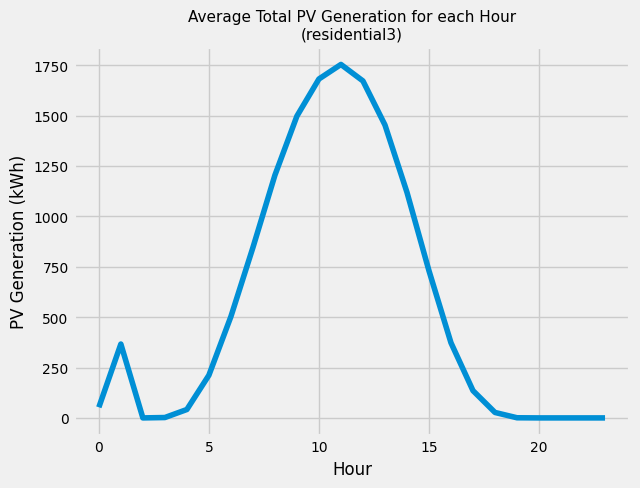

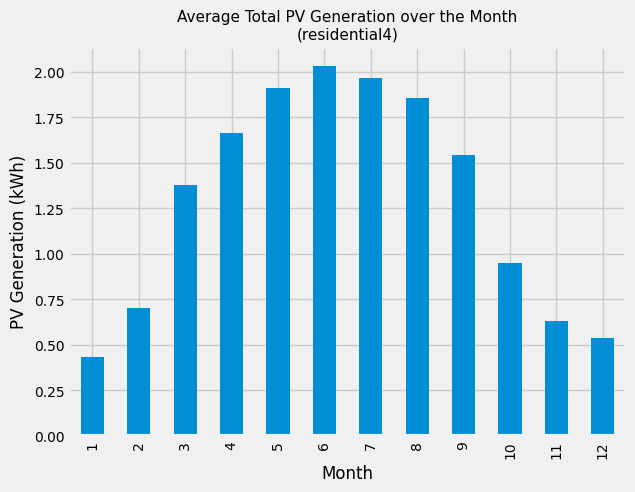

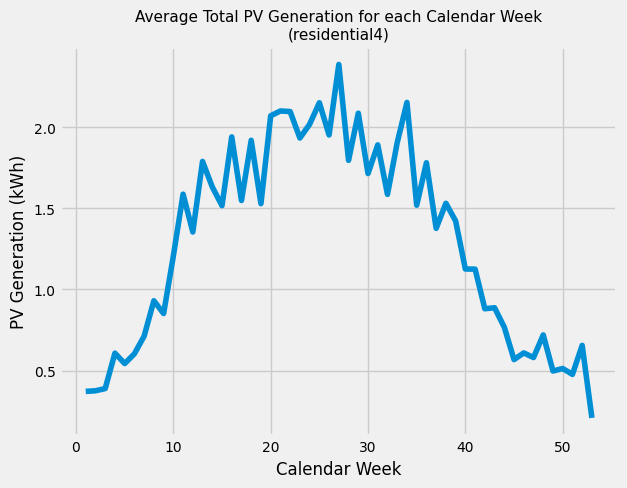

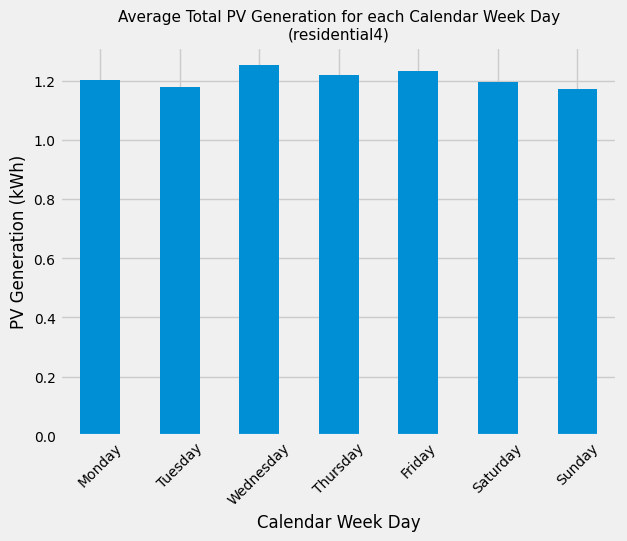

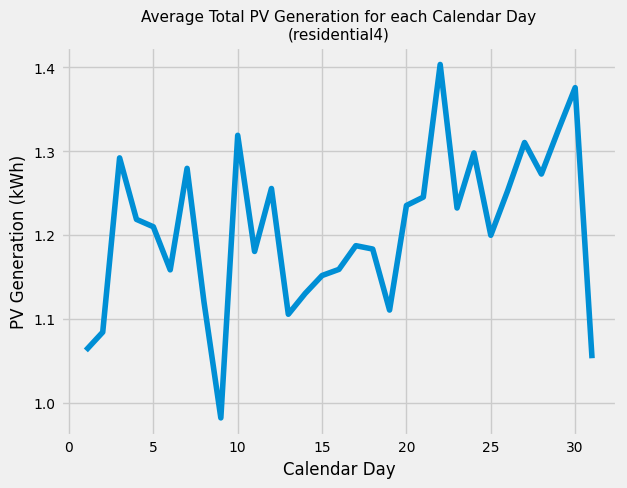

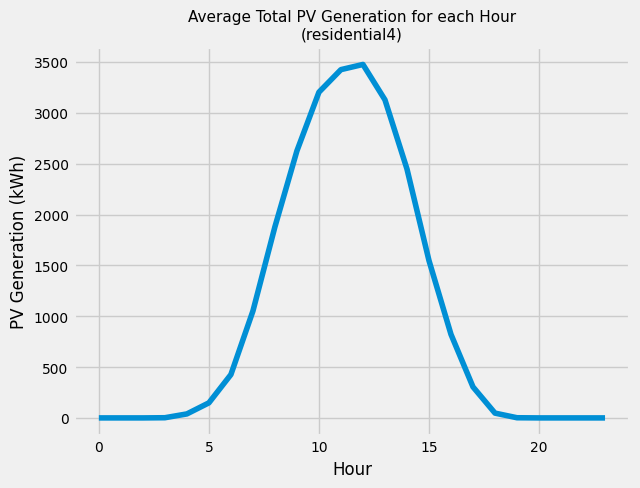

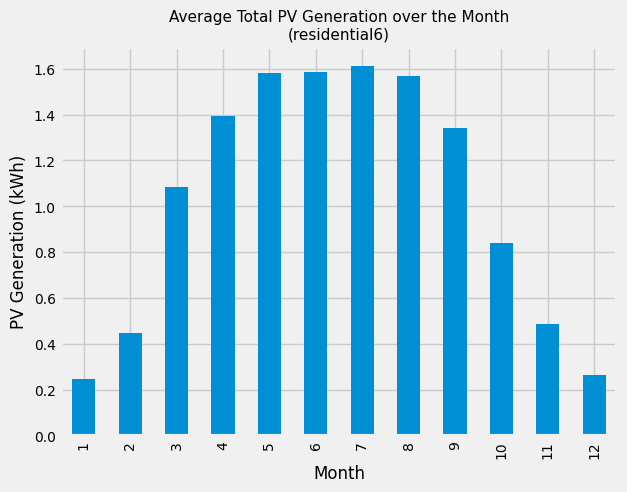

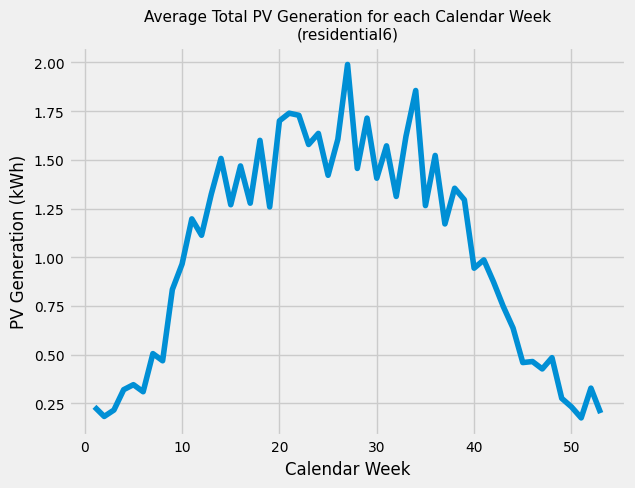

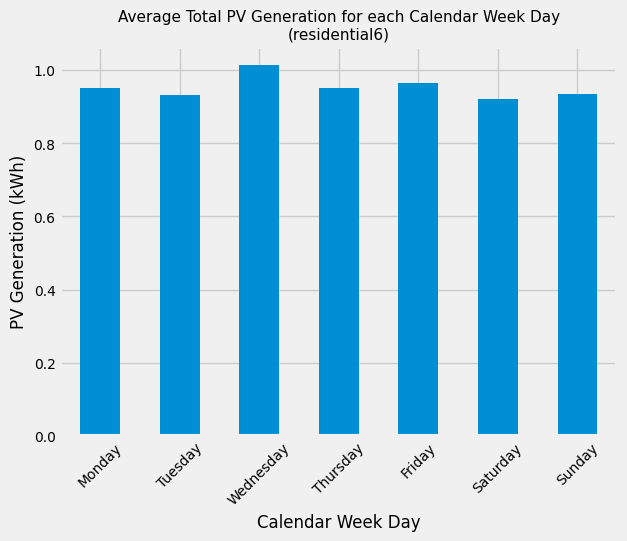

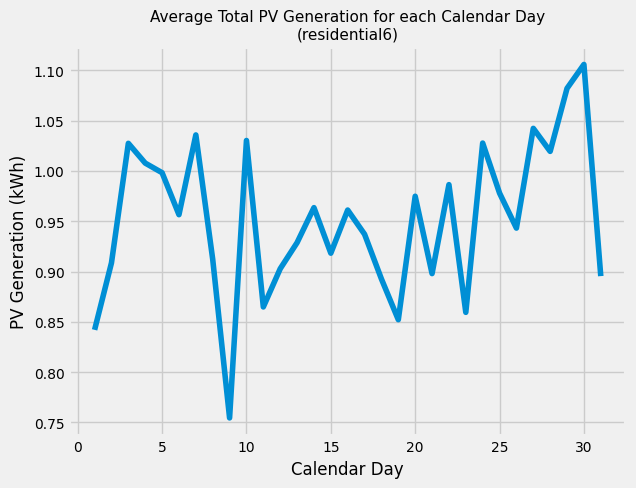

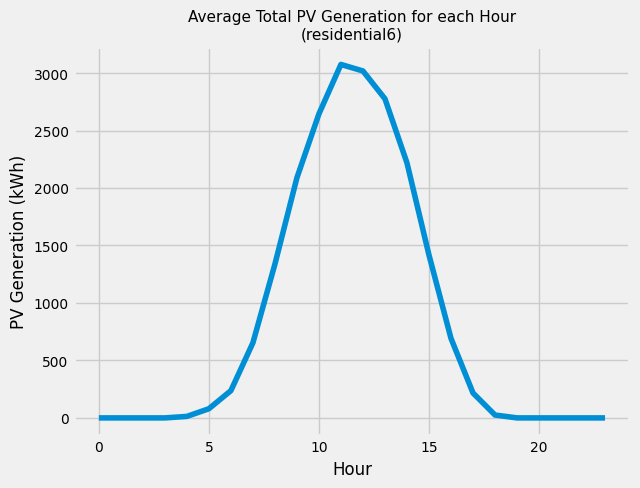

In [16]:
for hh, _ in hourly_household_df_dict.items():
    #print(f"The EDA feature plots for {hh!r}")
    
    df_ = hourly_household_df_dict[hh].copy()

    # Test whether a column exists or not
    feature_list = [col for col in date_feature_list if col in df_.columns]
    # Delete "year" from the list for better statistics
    feature_list.remove('year')
    
    #plt.style.use("")
    for feature in feature_list:
        eda_count_plot(df_, feature_dict, feature, hh)

In [17]:
# df_profile = ProfileReport(household_df_dict["residential1"].dropna(), title="Profiling Report")
# Export the profile report
# output_report = "../output/hh_profile_r1na.html"
# df_profile.to_file(output_report)

In [18]:
# ! open {output_report}

#### Flattened DataFrame

In [19]:
df_household.head()

,utc_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_grid_import,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine
0,2014-12-11 17:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11 18:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11 18:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11 18:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
name_dict = {
    "DE_KN_": "",
    "industrial1": "ind1",
    "industrial2": "ind2",
    "industrial3": "ind3",
    "residential1": "res1",
    "residential2": "res2",
    "residential3": "res3",
    "residential4": "res4",
    "residential5": "res5",
    "residential6": "res6",
}

for old_name, new_name in name_dict.items():
    #print(old_name, new_name)
    df_household.rename(columns=lambda col_name: col_name.replace(old_name, new_name) if old_name in col_name else col_name, inplace=True)

In [21]:
# Select only residentials
filter = df_household.columns.str.contains("^res[1346]") | df_household.columns.str.contains("^utc_")
df_household_filtered = df_household.loc[:, filter]

In [22]:
show_info(df_household_filtered)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,utc_timestamp,"datetime64[ns, UTC]",153810,0.00,153810,...
1,res1_dishwasher,float64,63378,58.79,2780,...
2,res1_freezer,float64,51580,66.47,45167,...
3,res1_grid_import,float64,63487,58.72,63487,...
4,res1_heat_pump,float64,63487,58.72,41337,...
5,res1_pv,float64,63487,58.72,29103,...
6,res1_washing_machine,float64,63381,58.79,8727,...
7,res3_circulation_pump,float64,132839,13.63,132782,...
8,res3_dishwasher,float64,116384,24.33,78980,...
9,res3_freezer,float64,114925,25.28,35443,...


- Missing value distribution Plot

<Axes: >

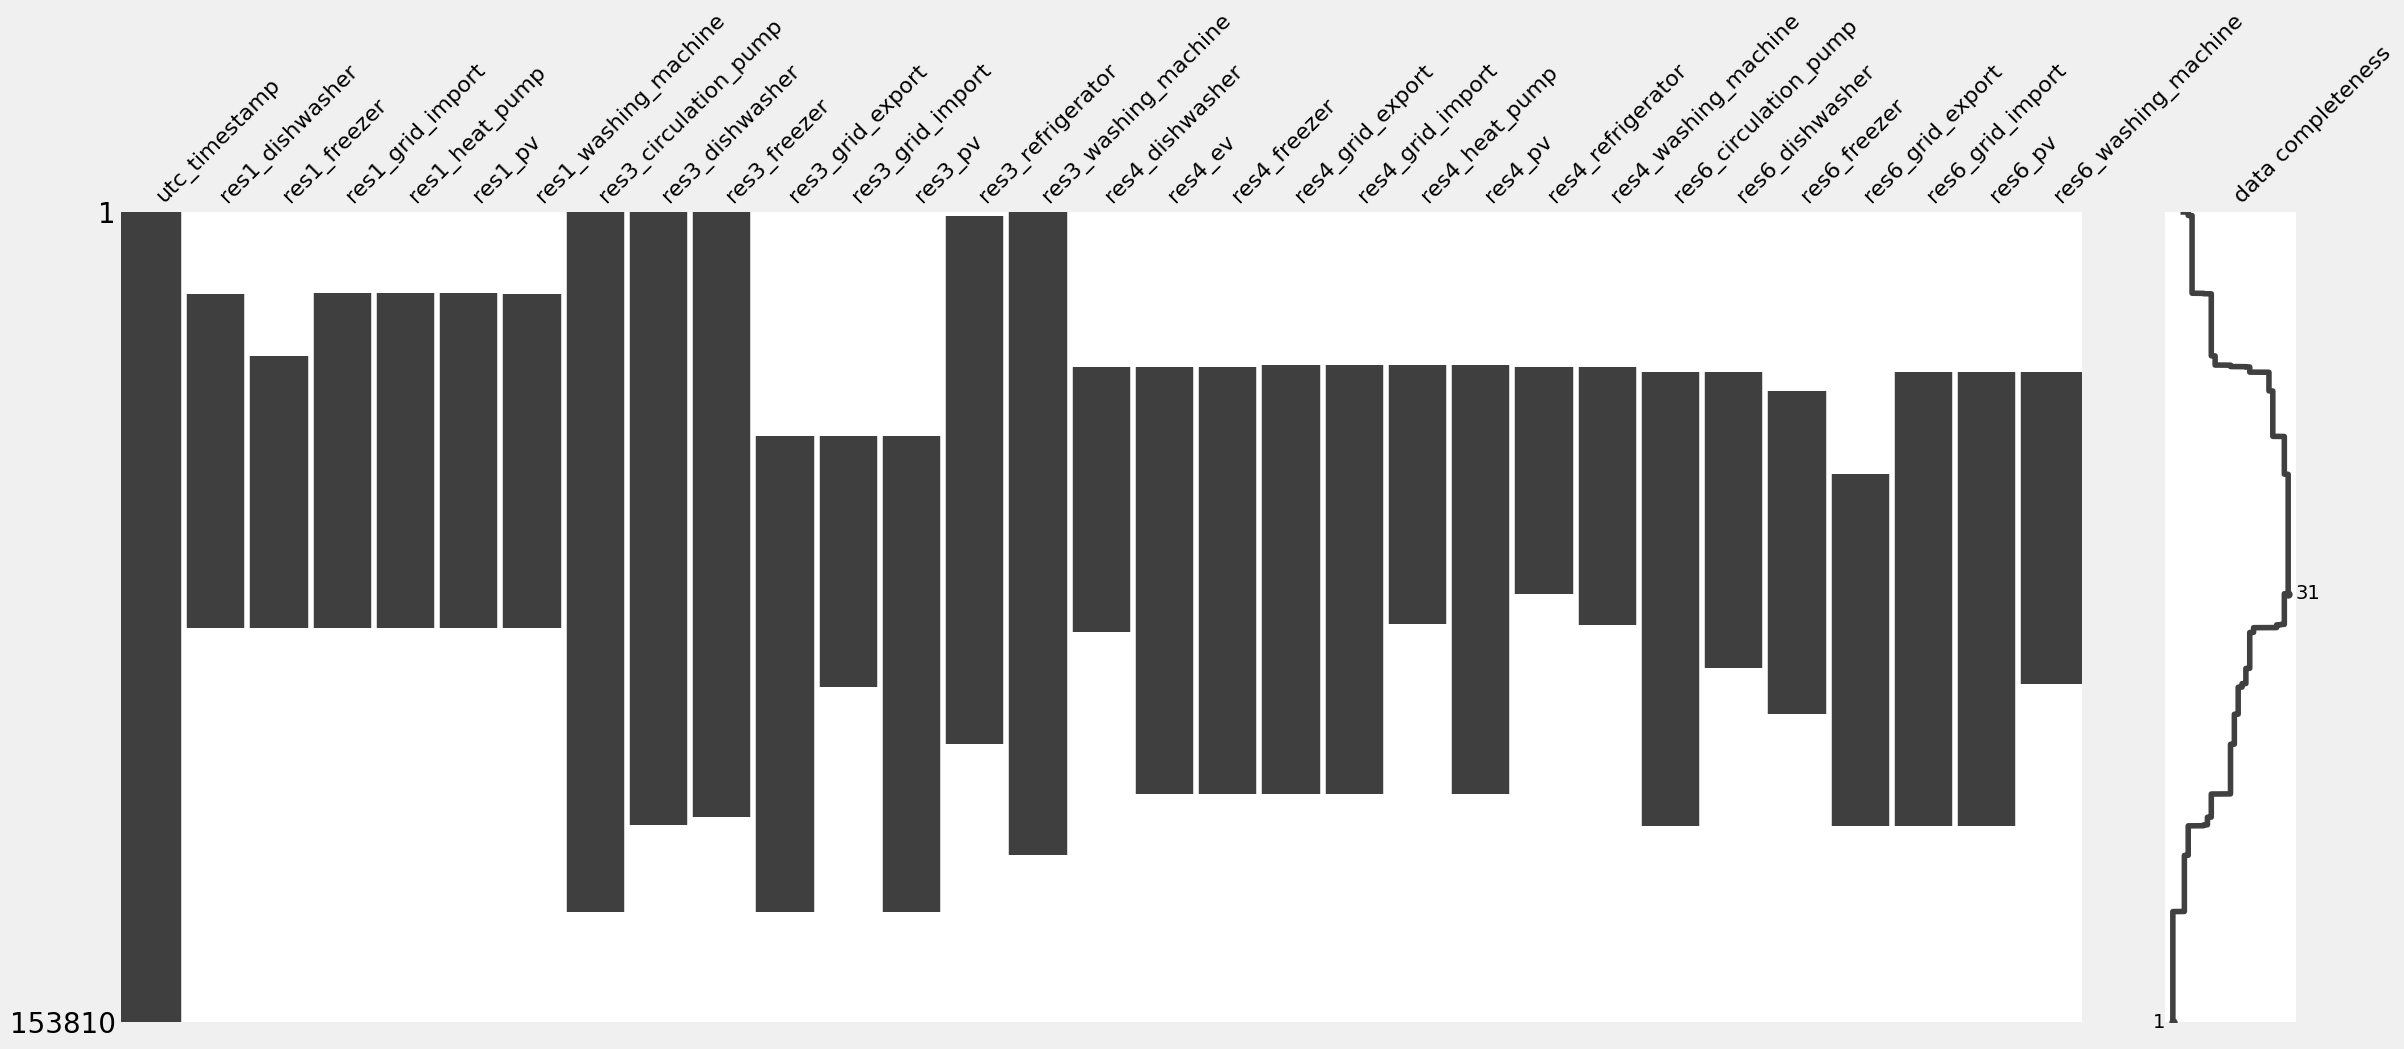

In [23]:
#plt.style.use("default")
#plt.style.use("ggplot")

msno.matrix(df_household_filtered, labels=True, sort=None)

<Axes: >

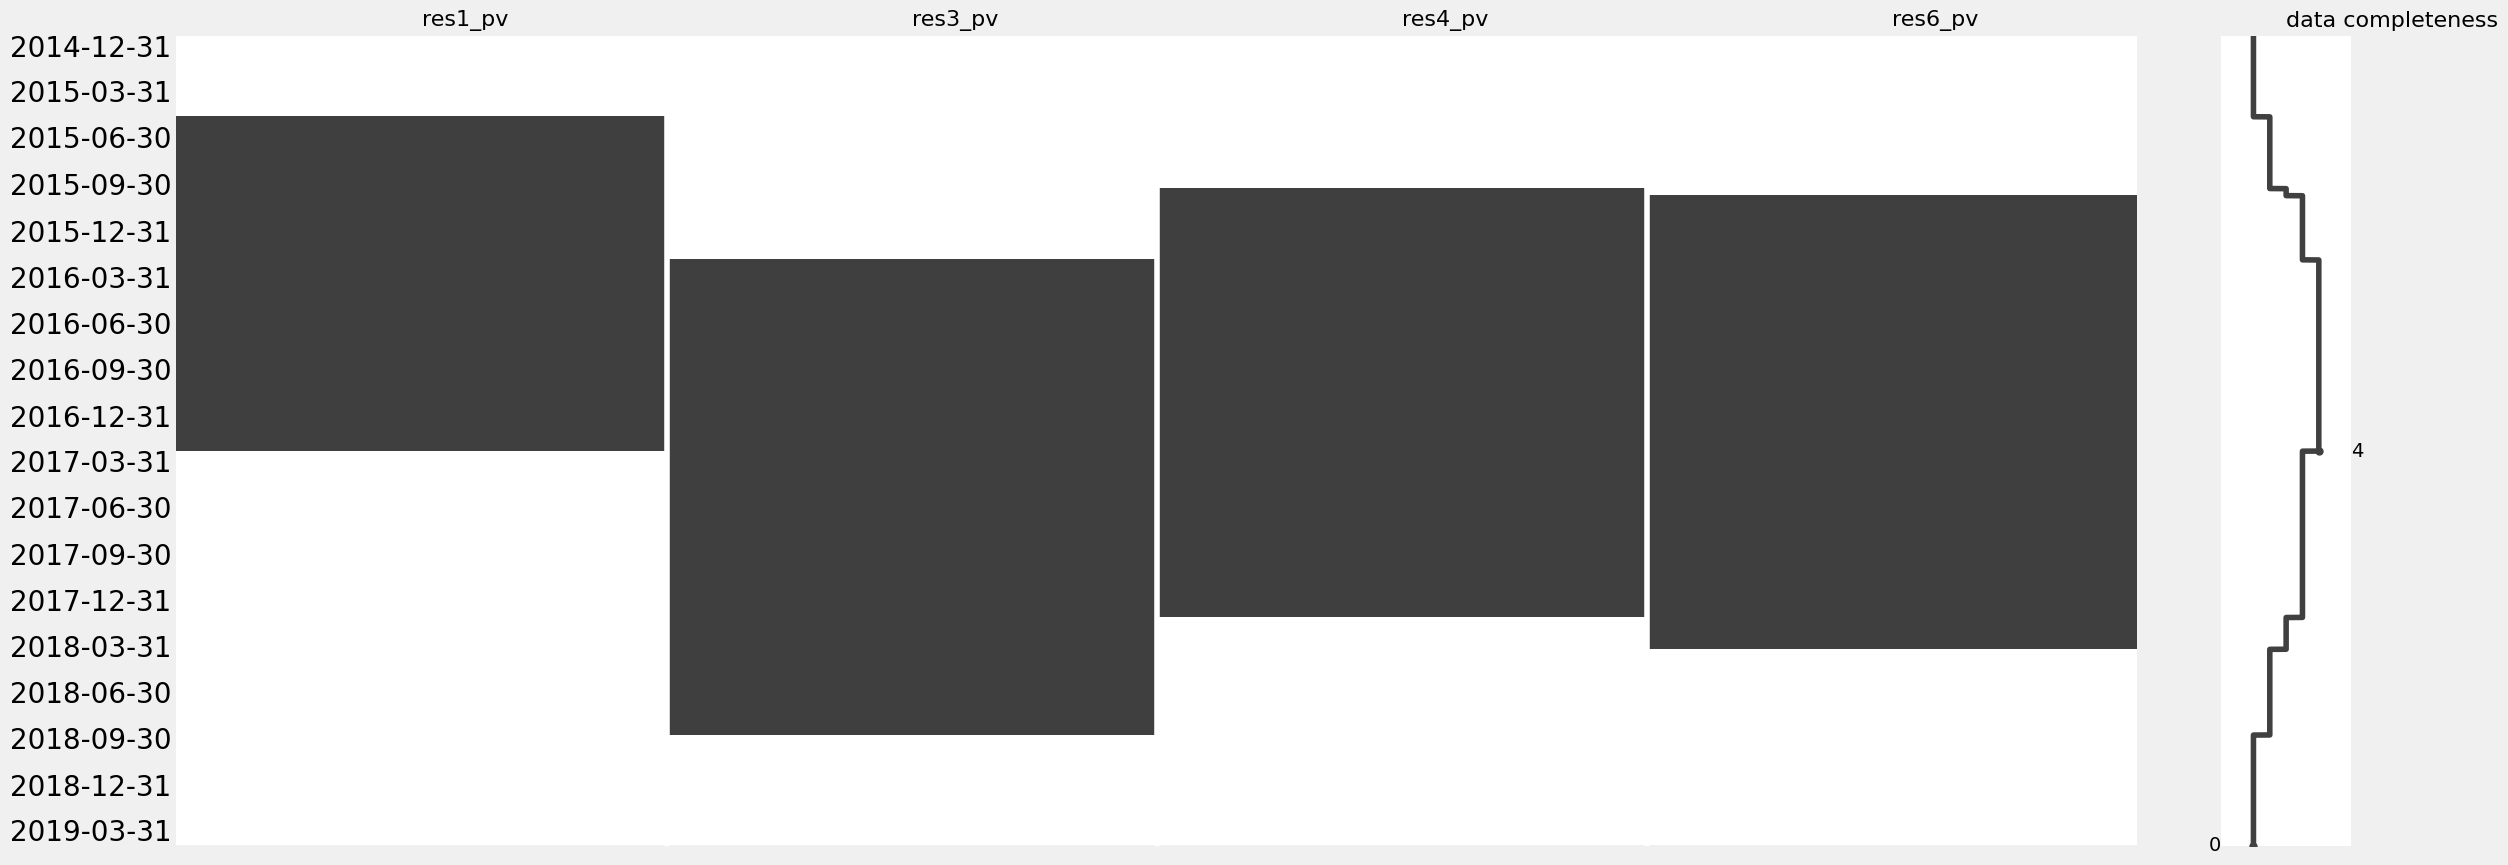

In [31]:
filter = df_household_filtered.columns.str.contains('_pv') | df_household_filtered.columns.str.contains('utc_')

df_household_pv = df_household_filtered.loc[:,filter].copy()
df_household_pv.set_index("utc_timestamp", inplace=True)
df_household_pv.index = df_household_pv.index.tz_localize(None)

msno.matrix(df_household_pv, freq="3M", labels=True, sort=None, label_rotation=0, fontsize=16)

In [25]:
def select_residential(df, res):
    df = df.copy()
    # Filter out those residentials having no pv generation data
    if res not in [f"res{i}" for i in [1,3,4,6]]:
        print(f"The residential {res!r} is not correct")
    
    # Set data time as the index
    df.set_index("utc_timestamp", inplace=True)
    df.index = df.index.tz_localize(None)

    # Mask only columns having 'res' in the name, excluding '_grid_export'
    filter = df.columns.str.contains(res) & ~df.columns.str.contains("_grid_ex")
    df_ = df.loc[:, filter].copy()

    # Get rid of prefix
    df_.columns = df_.columns.str.replace(f"{res}_", "")

    # Drop na and the first zeros according to 'pv'
    df_ = drop_na_and_zeros(df_, 'pv')

    # Store the original first row
    original_first_row = df_.iloc[0].copy()

    # Diff to get incremental data instead of cumusive data
    df_ = df_.diff()

    # Fill the first row using the original values
    df_.iloc[0] = 0 # original_first_row

    return df_

#
df_res1 = select_residential(df_household_filtered, "res1")
df_res3 = select_residential(df_household_filtered, "res3")
df_res4 = select_residential(df_household_filtered, "res4")
df_res6 = select_residential(df_household_filtered, "res6")

df_res1.head()

,dishwasher,freezer,grid_import,heat_pump,pv,washing_machine
utc_timestamp,,,,,,
2015-05-21 15:30:00,0.0,0.0,0.000,0.000,0.000,0.0
2015-05-21 15:45:00,NaN,NaN,0.079,0.010,0.078,NaN
2015-05-21 16:00:00,NaN,NaN,0.078,0.000,0.195,NaN
2015-05-21 16:15:00,NaN,NaN,0.080,0.000,0.231,NaN
2015-05-21 16:30:00,NaN,NaN,0.110,0.298,0.170,NaN


In [26]:
# df_profile = ProfileReport(df_res3, title="Profiling Report")
# Export the profile report
# output_report = "../output/hh_profile_r3.html"

# df_profile.to_file(output_report)

In [27]:
# ! open {output_report}